# **Shrek**

## ⚙️ **Notbook config**

In [1]:
# EDIT BEFORE USE
KAGGLE_API_PATH = "drive/MyDrive/[2025-2026] AN2DL/Challenges/"+"kaggle.json" # Google Drive path to your kaggle.json API credential file
SUBMIT_PREDICTION = True # Set to true to automatically send the submission to Kaggle
TRAIN_ON_WHOLE_SET = False # Set to true only the last day of the challenge to increase score of final selected model
GREEN_SLIME_PATH = "drive/MyDrive/[2025-2026] AN2DL/Challenges/Challenge2/green_slime.png"
HF_TOKEN = "hf_token"
BASE_PATH = "AN2DL_Challenge_2/Artifacts"

SHREKS_PATH = f"{BASE_PATH}/shreks/"
SLIMES_PATH = f"{BASE_PATH}/slimes/"

SHREK_RESULT_CSV_PATH = f"{BASE_PATH}/shrek_detection_results.csv"
SLIME_RESULT_CSV_PATH = f"{BASE_PATH}/slime_detection_results.csv"


# PARAMETERS
RESIZE_DIMENSION = [512, 512] # Resize width and height.
BATCH_SIZE = 32
APPLY_MASK=False
SPLIT_RATIO = 0.1 # Percentage of Validation set (e.g. 0.2 => 80% train, 20% validation)

# EDIT WITH CARE
IMAGES_PATH = "./an2dl2526c2v2/train_data"
SUBMISSION_IMAGES_PATH = "./an2dl2526c2v2/test_data"
LABELS_PATH = "./an2dl2526c2v2/"+"train_labels.csv"



## 📥 **Libraries Import**

In [2]:
# @title
# Set seed for reproducibility
SEED = 42

# Import standard libraries
import os
import random
import copy

import shutil
from itertools import product
import logging
import warnings

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import numerical and data libraries
import numpy as np
import pandas as pd

# Set seeds for random number generators
np.random.seed(SEED)
random.seed(SEED)

# Import plotting libraries
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

# Import image processing libraries
from PIL import Image

# Import sklearn modules
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Import Google Colab utilities
from google.colab import files

# Import PyTorch and related modules
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split, Subset
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
from torchsummary import summary

# Set PyTorch seeds and device
torch.manual_seed(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# TensorBoard setup and directories
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

# To be reordered

import os
import random
from pathlib import Path
from PIL import Image, ImageOps
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import pandas as pd

import timm
from huggingface_hub import login
# Login with your HF token (needed to access UNI weights)
login(token=HF_TOKEN)


PyTorch version: 2.9.0+cu126
Device: cuda


## ⏳ **Data Loading**

### Download

Import the dataset from Kaggle into this Google Colab Notebook **avoiding** downloading locally and then uploading here again, but using Kaggle APIs instead.
For this, creating a Kaggle API Token will be required. You can proceed through the following steps:

**Set up your Kaggle API credentials**
- Go to https://www.kaggle.com
 → click your profile picture → “Account”.

- Scroll down to the API section → click “Create New API Token”.
This downloads a file called kaggle.json (your API credentials).

- Upload kaggle.json file into your Drive

- Update the KAGGLE_API_PATH into CONFIG section of the notebook

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
if not os.path.exists('an2dl2526c2v2'):
    if KAGGLE_API_PATH is None:
        raise ValueError("KAGGLE_API_PATH environment variable is not set.")

    # Ensure the .kaggle directory exists
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

    # Copy kaggle.json from the given KAGGLE_API_PATH
    !cp "$KAGGLE_API_PATH" ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json

    # Download the competition dataset
    !kaggle competitions download -c an2dl2526c2v2

    # Extract and clean up
    !unzip -o -q an2dl2526c2v2.zip -d ./an2dl2526c2v2
    !rm an2dl2526c2v2.zip
else:
    print("Dataset already exists. Skipping download.")


 89% 831M/936M [00:00<00:00, 1.21GB/s]
100% 936M/936M [00:00<00:00, 1.35GB/s]


In [5]:
#!unzip -o -q "drive/MyDrive/[2025-2026] AN2DL/Challenges/Challenge2/an2dl2526c2v2.zip" -d ./an2dl2526c2v2


## 🩻 Artifacts Detection via CNN

In [6]:
!git clone https://github.com/AleCava01/AN2DL_Challenge_2.git

Cloning into 'AN2DL_Challenge_2'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 74 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 27.03 MiB | 16.10 MiB/s, done.
Resolving deltas: 100% (5/5), done.


### Shreks

In [7]:
if os.path.exists(SHREK_RESULT_CSV_PATH):
  print("⚠️  Skipping Shrek detection pipeline: CSV already exists at:")
  print("   ", SHREK_RESULT_CSV_PATH)
  shrek_df_results = pd.read_csv(SHREK_RESULT_CSV_PATH)
else:
  # -----------------------
  # USER CONFIG
  # -----------------------
  SHREK_WORK_DIR = "./shrek_cnn_work"
  SHREK_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  SHREK_BATCH_SIZE = 32
  SHREK_NUM_EPOCHS = 4
  SHREK_LR = 1e-3
  SHREK_MODEL_PATH = os.path.join(SHREK_WORK_DIR, "shrek_cnn.pth")
  SHREK_THRESHOLD = 1e-2
  SHREK_IMAGE_SIZE = 224
  SHREK_SYNTH_POS = 2000
  SHREK_SYNTH_NEG = 2000

  SHREK_PATTERNS_FOLDER = SHREKS_PATH  # folder with Shrek pattern templates

  os.makedirs(SHREK_WORK_DIR, exist_ok=True)

  # -----------------------
  # UTILITY
  # -----------------------
  def load_shrek_image(path):
      try:
          return Image.open(path).convert("RGB")
      except Exception as e:
          print("Failed to open", path, e)
          return None

  # -----------------------
  # SYNTHETIC DATASET (multi-pattern)
  # -----------------------
  def create_shrek_synthetic_dataset(images_dir, patterns_dir, out_dir, n_pos, n_neg, image_size=SHREK_IMAGE_SIZE):
      out_dir = Path(out_dir)
      shrek_pos_dir = out_dir / "pos"
      shrek_neg_dir = out_dir / "neg"
      shrek_pos_dir.mkdir(parents=True, exist_ok=True)
      shrek_neg_dir.mkdir(parents=True, exist_ok=True)

      bg_paths = [p for p in Path(images_dir).glob("img_*") if p.suffix.lower() in [".png", ".jpg", ".jpeg"]]
      if not bg_paths:
          raise FileNotFoundError(f"No background images in {images_dir}")

      pattern_paths = [p for p in Path(patterns_dir).glob("*") if p.suffix.lower() in [".png", ".jpg", ".jpeg"]]
      if not pattern_paths:
          raise FileNotFoundError(f"No pattern templates in {patterns_dir}")

      def random_transform_shrek(tpl):
          s = random.uniform(0.5, 1.5)
          w, h = tpl.size
          tpl = tpl.resize((max(10,int(w*s)), max(10,int(h*s))), Image.BILINEAR)
          tpl = tpl.rotate(random.uniform(-45,45), expand=True)
          if random.random()<0.5:
              tpl = ImageOps.mirror(tpl)
          return tpl

      def paste_shrek_on_bg(bg, tpl):
          bw, bh = bg.size
          tw, th = tpl.size
          if tw >= bw or th >= bh:
              scale = min((bw-10)/tw, (bh-10)/th, 1.0)
              tpl = tpl.resize((int(tw*scale), int(th*scale)), Image.BILINEAR)
              tw, th = tpl.size
          x, y = random.randint(0,bw-tw), random.randint(0,bh-th)
          if tpl.mode=="RGBA":
              alpha = np.array(tpl.split()[-1])/255.0
              rgb = np.array(tpl.convert("RGB")).astype(np.uint8)
              bg_arr = np.array(bg).astype(np.uint8)
              for c in range(3):
                  bg_arr[y:y+th, x:x+tw, c] = (alpha*rgb[:,:,c] + (1-alpha)*bg_arr[y:y+th, x:x+tw, c]).astype(np.uint8)
              return Image.fromarray(bg_arr)
          else:
              bg.paste(tpl, (x,y), None)
              return bg

      pbar = tqdm(total=n_pos+n_neg, desc="Creating Shrek synthetic dataset")
      # positive
      for i in range(n_pos):
          bg = load_shrek_image(random.choice(bg_paths))
          if bg is None: continue
          bg = bg.copy()
          if bg.width<image_size or bg.height<image_size:
              bg = bg.resize((max(image_size,bg.width), max(image_size,bg.height)), Image.BILINEAR)
          left, top = random.randint(0,bg.width-image_size), random.randint(0,bg.height-image_size)
          bg_crop = bg.crop((left, top, left+image_size, top+image_size))
          tpl = load_shrek_image(random.choice(pattern_paths))
          tpl_t = random_transform_shrek(tpl)
          synth = paste_shrek_on_bg(bg_crop, tpl_t)
          synth.save(shrek_pos_dir / f"pos_{i:05d}.jpg", quality=90)
          pbar.update(1)
      # negative
      for i in range(n_neg):
          bg = load_shrek_image(random.choice(bg_paths))
          if bg is None: continue
          bg = bg.copy()
          if bg.width<image_size or bg.height<image_size:
              bg = bg.resize((max(image_size,bg.width), max(image_size,bg.height)), Image.BILINEAR)
          left, top = random.randint(0,bg.width-image_size), random.randint(0,bg.height-image_size)
          bg_crop = bg.crop((left, top, left+image_size, top+image_size))
          bg_crop.save(shrek_neg_dir / f"neg_{i:05d}.jpg", quality=90)
          pbar.update(1)

      pbar.close()
      print("Shrek synthetic dataset created at:", out_dir)
      return shrek_pos_dir, shrek_neg_dir

  # -----------------------
  # DATASET CLASS
  # -----------------------
  class ShrekImageDataset(Dataset):
      def __init__(self, paths, labels, transform=None):
          self.paths = list(paths)
          self.labels = labels
          self.transform = transform
      def __len__(self):
          return len(self.paths)
      def __getitem__(self, idx):
          p = self.paths[idx]
          img = load_shrek_image(p)
          if img is None:
              img = Image.new("RGB", (SHREK_IMAGE_SIZE, SHREK_IMAGE_SIZE), (0,0,0))
          if self.transform:
              img = self.transform(img)
          label = torch.tensor(self.labels[idx], dtype=torch.float32)
          return img, label

  # -----------------------
  # SMALL CNN MODEL
  # -----------------------
  class ShrekCNN(nn.Module):
      def __init__(self):
          super().__init__()
          self.features = nn.Sequential(
              nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
              nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
              nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
              nn.Conv2d(128,256,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
              nn.AdaptiveAvgPool2d((1,1))
          )
          self.classifier = nn.Sequential(
              nn.Flatten(),
              nn.Linear(256,128), nn.ReLU(), nn.Dropout(0.3),
              nn.Linear(128,1)
          )
      def forward(self,x):
          x = self.features(x)
          return self.classifier(x).squeeze(1)

  # -----------------------
  # TRAINING FUNCTION
  # -----------------------
  def train_shrek_model(train_loader, val_loader, model, device, epochs=SHREK_NUM_EPOCHS, lr=SHREK_LR):
      model.to(device)
      opt = torch.optim.Adam(model.parameters(), lr=lr)
      criterion = nn.BCEWithLogitsLoss()
      best_val_loss = float("inf")
      for epoch in range(epochs):
          model.train()
          running_loss = 0.0
          for xb, yb in tqdm(train_loader, desc=f"Train Shrek epoch {epoch+1}/{epochs}"):
              xb, yb = xb.to(device), yb.to(device)
              opt.zero_grad()
              loss = criterion(model(xb), yb)
              loss.backward()
              opt.step()
              running_loss += loss.item()*xb.size(0)
          train_loss = running_loss / len(train_loader.dataset)

          model.eval()
          vloss = 0.0
          with torch.no_grad():
              for xb, yb in val_loader:
                  xb, yb = xb.to(device), yb.to(device)
                  loss = criterion(model(xb), yb)
                  vloss += loss.item()*xb.size(0)
          val_loss = vloss / len(val_loader.dataset)
          print(f"Epoch {epoch+1} — train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}")
          if val_loss < best_val_loss:
              best_val_loss = val_loss
              torch.save(model.state_dict(), SHREK_MODEL_PATH)
              print("Saved best Shrek model.")
      model.load_state_dict(torch.load(SHREK_MODEL_PATH, map_location=device))
      return model

  # -----------------------
  # INFERENCE FUNCTION
  # -----------------------
  def shrek_inference_on_folder(model, images_folder, device, threshold=SHREK_THRESHOLD, image_size=SHREK_IMAGE_SIZE):
      model.to(device)
      model.eval()
      preprocess = transforms.Compose([
          transforms.Resize((image_size,image_size)),
          transforms.ToTensor(),
          transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
      ])
      rows = []
      for p in sorted(Path(images_folder).glob("img_*")):
          if p.suffix.lower() not in [".png",".jpg",".jpeg"]:
              continue
          img = load_shrek_image(p)
          if img is None:
              continue
          x = preprocess(img).unsqueeze(0).to(device)
          with torch.no_grad():
              prob = torch.sigmoid(model(x)).item()
          detected = prob >= threshold
          rows.append({"filename": p.name, "prob": prob, "contains_pattern": detected})
      return pd.DataFrame(rows)

  # -----------------------
  # TRANSFORMS
  # -----------------------
  shrek_train_transforms = transforms.Compose([
      transforms.RandomResizedCrop(SHREK_IMAGE_SIZE, scale=(0.6,1.0)),
      transforms.RandomHorizontalFlip(),
      transforms.RandomRotation(30),
      transforms.ColorJitter(0.3,0.3,0.2),
      transforms.ToTensor(),
      transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
  ])
  shrek_val_transforms = transforms.Compose([
      transforms.Resize((SHREK_IMAGE_SIZE,SHREK_IMAGE_SIZE)),
      transforms.ToTensor(),
      transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
  ])

  # -----------------------
  # CREATE SYNTHETIC SHREK DATASET
  # -----------------------
  shrek_synth_dir = os.path.join(SHREK_WORK_DIR,"synthetic")
  shrek_pos_dir, shrek_neg_dir = create_shrek_synthetic_dataset(IMAGES_PATH, SHREK_PATTERNS_FOLDER, shrek_synth_dir, SHREK_SYNTH_POS, SHREK_SYNTH_NEG)

  # -----------------------
  # COLLECT FILES & SPLIT
  # -----------------------
  shrek_pos_files = list(Path(shrek_pos_dir).glob("*.jpg"))
  shrek_neg_files = list(Path(shrek_neg_dir).glob("*.jpg"))
  shrek_all_files = shrek_pos_files + shrek_neg_files
  shrek_labels = [1]*len(shrek_pos_files) + [0]*len(shrek_neg_files)
  shrek_combined = list(zip(shrek_all_files, shrek_labels))
  random.shuffle(shrek_combined)
  split = int(0.8*len(shrek_combined))
  shrek_train_paths, shrek_train_labels = zip(*shrek_combined[:split])
  shrek_val_paths, shrek_val_labels = zip(*shrek_combined[split:])
  shrek_train_ds = ShrekImageDataset(shrek_train_paths, shrek_train_labels, transform=shrek_train_transforms)
  shrek_val_ds = ShrekImageDataset(shrek_val_paths, shrek_val_labels, transform=shrek_val_transforms)
  shrek_train_loader = DataLoader(shrek_train_ds, batch_size=SHREK_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
  shrek_val_loader = DataLoader(shrek_val_ds, batch_size=SHREK_BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

  # -----------------------
  # TRAIN SHREK MODEL
  # -----------------------
  shrek_model = ShrekCNN()
  shrek_model = train_shrek_model(shrek_train_loader, shrek_val_loader, shrek_model, SHREK_DEVICE)
  print("Training finished. Shrek model saved to:", SHREK_MODEL_PATH)

  # -----------------------
  # INFERENCE
  # -----------------------
  shrek_df_results = shrek_inference_on_folder(shrek_model, IMAGES_PATH, SHREK_DEVICE)
  shrek_df_results.to_csv(SHREK_RESULT_CSV_PATH, index=False)
  print("Saved Shrek detection results to", SHREK_RESULT_CSV_PATH)


⚠️  Skipping Shrek detection pipeline: CSV already exists at:
    AN2DL_Challenge_2/Artifacts/shrek_detection_results.csv


#### Display some results

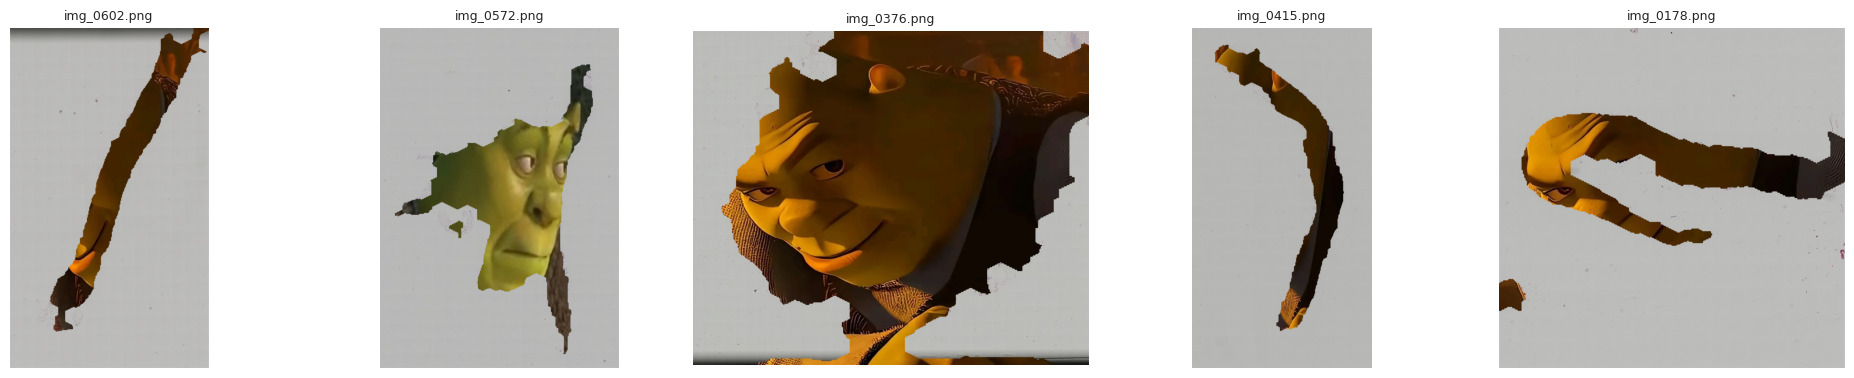

In [8]:
# @title
import matplotlib.pyplot as plt
from PIL import Image
import os

# Filter only detected "shrek" images
detected_results = shrek_df_results[shrek_df_results.contains_pattern == True]

# Take up to 20 images
sample_results = detected_results.sample(n=min(5, len(detected_results)), random_state=23)

per_row = 5
rows = (len(sample_results) + per_row - 1) // per_row
plt.figure(figsize=(per_row * 4, rows * 4))

for i, row in enumerate(sample_results.itertuples(), 1):
    img_path = os.path.join(IMAGES_PATH, row.filename)
    try:
        img = Image.open(img_path).convert("RGB")
    except:
        continue
    ax = plt.subplot(rows, per_row, i)
    ax.imshow(img)
    ax.set_title(row.filename, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


### Green Slimes

In [9]:
if os.path.exists(SLIME_RESULT_CSV_PATH):
    print("✔ slime_detection_results.csv already exists — skipping Slime pipeline.")
    slime_df_results = pd.read_csv(SLIME_RESULT_CSV_PATH)
else:
    print("✚ slime_detection_results.csv not found — running Slime pipeline.")
    # -----------------------
    # USER CONFIG
    # -----------------------
    SLIME_WORK_DIR = "./slime_cnn_work"
    SLIME_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SLIME_BATCH_SIZE = 32
    SLIME_NUM_EPOCHS = 4
    SLIME_LR = 1e-3
    SLIME_MODEL_PATH = os.path.join(SLIME_WORK_DIR, "slime_cnn.pth")
    SLIME_THRESHOLD = 1e-2
    SLIME_IMAGE_SIZE = 224
    SLIME_SYNTH_POS = 2000
    SLIME_SYNTH_NEG = 2000

    SLIME_PATTERNS_FOLDER = SLIMES_PATH  # folder with Slime pattern templates

    os.makedirs(SLIME_WORK_DIR, exist_ok=True)

    # -----------------------
    # UTILITY
    # -----------------------
    def load_slime_image(path):
        try:
            return Image.open(path).convert("RGB")
        except Exception as e:
            print("Failed to open", path, e)
            return None

    # -----------------------
    # SYNTHETIC DATASET (multi-pattern)
    # -----------------------
    def create_slime_synthetic_dataset(images_dir, patterns_dir, out_dir, n_pos, n_neg, image_size=SLIME_IMAGE_SIZE):
        out_dir = Path(out_dir)
        slime_pos_dir = out_dir / "pos"
        slime_neg_dir = out_dir / "neg"
        slime_pos_dir.mkdir(parents=True, exist_ok=True)
        slime_neg_dir.mkdir(parents=True, exist_ok=True)

        bg_paths = [p for p in Path(images_dir).glob("img_*") if p.suffix.lower() in [".png", ".jpg", ".jpeg"]]
        if not bg_paths:
            raise FileNotFoundError(f"No background images in {images_dir}")

        pattern_paths = [p for p in Path(patterns_dir).glob("*") if p.suffix.lower() in [".png", ".jpg", ".jpeg"]]
        if not pattern_paths:
            raise FileNotFoundError(f"No pattern templates in {patterns_dir}")

        def random_transform_slime(tpl):
            s = random.uniform(0.5, 1.5)
            w, h = tpl.size
            tpl = tpl.resize((max(10,int(w*s)), max(10,int(h*s))), Image.BILINEAR)
            tpl = tpl.rotate(random.uniform(-45,45), expand=True)
            if random.random()<0.5:
                tpl = ImageOps.mirror(tpl)
            return tpl

        def paste_slime_on_bg(bg, tpl):
            bw, bh = bg.size
            tw, th = tpl.size
            if tw >= bw or th >= bh:
                scale = min((bw-10)/tw, (bh-10)/th, 1.0)
                tpl = tpl.resize((int(tw*scale), int(th*scale)), Image.BILINEAR)
                tw, th = tpl.size
            x, y = random.randint(0,bw-tw), random.randint(0,bh-th)
            if tpl.mode=="RGBA":
                alpha = np.array(tpl.split()[-1])/255.0
                rgb = np.array(tpl.convert("RGB")).astype(np.uint8)
                bg_arr = np.array(bg).astype(np.uint8)
                for c in range(3):
                    bg_arr[y:y+th, x:x+tw, c] = (alpha*rgb[:,:,c] + (1-alpha)*bg_arr[y:y+th, x:x+tw, c]).astype(np.uint8)
                return Image.fromarray(bg_arr)
            else:
                bg.paste(tpl, (x,y), None)
                return bg

        pbar = tqdm(total=n_pos+n_neg, desc="Creating Slime synthetic dataset")
        # positive
        for i in range(n_pos):
            bg = load_slime_image(random.choice(bg_paths))
            if bg is None: continue
            bg = bg.copy()
            if bg.width<image_size or bg.height<image_size:
                bg = bg.resize((max(image_size,bg.width), max(image_size,bg.height)), Image.BILINEAR)
            left, top = random.randint(0,bg.width-image_size), random.randint(0,bg.height-image_size)
            bg_crop = bg.crop((left, top, left+image_size, top+image_size))
            tpl = load_slime_image(random.choice(pattern_paths))
            tpl_t = random_transform_slime(tpl)
            synth = paste_slime_on_bg(bg_crop, tpl_t)
            synth.save(slime_pos_dir / f"pos_{i:05d}.jpg", quality=90)
            pbar.update(1)
        # negative
        for i in range(n_neg):
            bg = load_slime_image(random.choice(bg_paths))
            if bg is None: continue
            bg = bg.copy()
            if bg.width<image_size or bg.height<image_size:
                bg = bg.resize((max(image_size,bg.width), max(image_size,bg.height)), Image.BILINEAR)
            left, top = random.randint(0,bg.width-image_size), random.randint(0,bg.height-image_size)
            bg_crop = bg.crop((left, top, left+image_size, top+image_size))
            bg_crop.save(slime_neg_dir / f"neg_{i:05d}.jpg", quality=90)
            pbar.update(1)

        pbar.close()
        print("Slime synthetic dataset created at:", out_dir)
        return slime_pos_dir, slime_neg_dir

    # -----------------------
    # DATASET CLASS
    # -----------------------
    class SlimeImageDataset(Dataset):
        def __init__(self, paths, labels, transform=None):
            self.paths = list(paths)
            self.labels = labels
            self.transform = transform
        def __len__(self):
            return len(self.paths)
        def __getitem__(self, idx):
            p = self.paths[idx]
            img = load_slime_image(p)
            if img is None:
                img = Image.new("RGB", (SLIME_IMAGE_SIZE, SLIME_IMAGE_SIZE), (0,0,0))
            if self.transform:
                img = self.transform(img)
            label = torch.tensor(self.labels[idx], dtype=torch.float32)
            return img, label

    # -----------------------
    # SMALL CNN MODEL
    # -----------------------
    class SlimeCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(128,256,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.AdaptiveAvgPool2d((1,1))
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(256,128), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(128,1)
            )
        def forward(self,x):
            x = self.features(x)
            return self.classifier(x).squeeze(1)

    # -----------------------
    # TRAINING FUNCTION
    # -----------------------
    def train_slime_model(train_loader, val_loader, model, device, epochs=SLIME_NUM_EPOCHS, lr=SLIME_LR):
        model.to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.BCEWithLogitsLoss()
        best_val_loss = float("inf")
        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            for xb, yb in tqdm(train_loader, desc=f"Train Slime epoch {epoch+1}/{epochs}"):
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                opt.step()
                running_loss += loss.item()*xb.size(0)
            train_loss = running_loss / len(train_loader.dataset)

            model.eval()
            vloss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    loss = criterion(model(xb), yb)
                    vloss += loss.item()*xb.size(0)
            val_loss = vloss / len(val_loader.dataset)
            print(f"Epoch {epoch+1} — train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}")
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), SLIME_MODEL_PATH)
                print("Saved best Slime model.")
        model.load_state_dict(torch.load(SLIME_MODEL_PATH, map_location=device))
        return model

    # -----------------------
    # INFERENCE FUNCTION
    # -----------------------
    def slime_inference_on_folder(model, images_folder, device, threshold=SLIME_THRESHOLD, image_size=SLIME_IMAGE_SIZE):
        model.to(device)
        model.eval()
        preprocess = transforms.Compose([
            transforms.Resize((image_size,image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        rows = []
        for p in sorted(Path(images_folder).glob("img_*")):
            if p.suffix.lower() not in [".png",".jpg",".jpeg"]:
                continue
            img = load_slime_image(p)
            if img is None:
                continue
            x = preprocess(img).unsqueeze(0).to(device)
            with torch.no_grad():
                prob = torch.sigmoid(model(x)).item()
            detected = prob >= threshold
            rows.append({"filename": p.name, "prob": prob, "contains_pattern": detected})
        return pd.DataFrame(rows)

    # -----------------------
    # TRANSFORMS
    # -----------------------
    slime_train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(SLIME_IMAGE_SIZE, scale=(0.6,1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(0.3,0.3,0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    slime_val_transforms = transforms.Compose([
        transforms.Resize((SLIME_IMAGE_SIZE,SLIME_IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    # -----------------------
    # CREATE SYNTHETIC SLIME DATASET
    # -----------------------
    slime_synth_dir = os.path.join(SLIME_WORK_DIR,"synthetic")
    slime_pos_dir, slime_neg_dir = create_slime_synthetic_dataset(IMAGES_PATH, SLIME_PATTERNS_FOLDER, slime_synth_dir, SLIME_SYNTH_POS, SLIME_SYNTH_NEG)

    # -----------------------
    # COLLECT FILES & SPLIT
    # -----------------------
    slime_pos_files = list(Path(slime_pos_dir).glob("*.jpg"))
    slime_neg_files = list(Path(slime_neg_dir).glob("*.jpg"))
    slime_all_files = slime_pos_files + slime_neg_files
    slime_labels = [1]*len(slime_pos_files) + [0]*len(slime_neg_files)
    slime_combined = list(zip(slime_all_files, slime_labels))
    random.shuffle(slime_combined)
    split = int(0.8*len(slime_combined))
    slime_train_paths, slime_train_labels = zip(*slime_combined[:split])
    slime_val_paths, slime_val_labels = zip(*slime_combined[split:])
    slime_train_ds = SlimeImageDataset(slime_train_paths, slime_train_labels, transform=slime_train_transforms)
    slime_val_ds = SlimeImageDataset(slime_val_paths, slime_val_labels, transform=slime_val_transforms)
    slime_train_loader = DataLoader(slime_train_ds, batch_size=SLIME_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    slime_val_loader = DataLoader(slime_val_ds, batch_size=SLIME_BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

    # -----------------------
    # TRAIN SLIME MODEL
    # -----------------------
    slime_model = SlimeCNN()
    slime_model = train_slime_model(slime_train_loader, slime_val_loader, slime_model, SLIME_DEVICE)
    print("Training finished. Slime model saved to:", SLIME_MODEL_PATH)

    # -----------------------
    # INFERENCE
    # -----------------------
    slime_df_results = slime_inference_on_folder(slime_model, IMAGES_PATH, SLIME_DEVICE)
    slime_df_results.to_csv(SLIME_RESULT_CSV_PATH, index=False)
    print("Saved Slime detection results to", SLIME_RESULT_CSV_PATH)

✔ slime_detection_results.csv already exists — skipping Slime pipeline.


#### Display some results

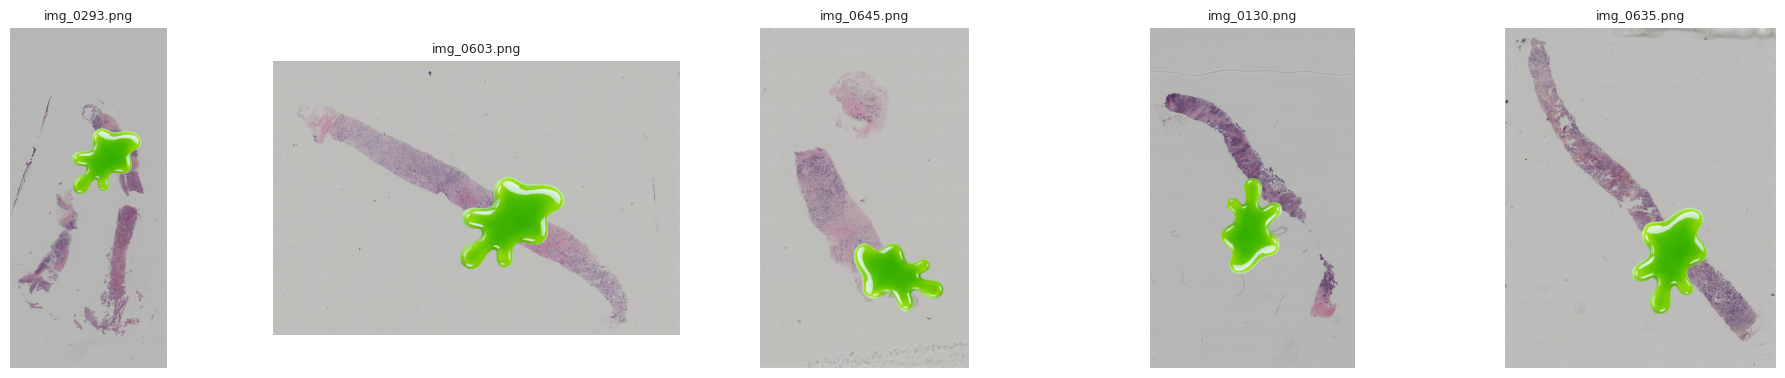

In [10]:
# @title
import matplotlib.pyplot as plt
from PIL import Image
import os

# Filter only detected "slime" images
detected_slimes = slime_df_results[slime_df_results.contains_pattern == True]

# Take up to 20 images
sample_slimes = detected_slimes.sample(n=min(5, len(detected_slimes)), random_state=42)

per_row = 5
rows = (len(sample_slimes) + per_row - 1) // per_row
plt.figure(figsize=(per_row * 4, rows * 4))

for i, row in enumerate(sample_slimes.itertuples(), 1):
    img_path = os.path.join(IMAGES_PATH, row.filename)
    try:
        img = Image.open(img_path).convert("RGB")
    except:
        continue
    ax = plt.subplot(rows, per_row, i)
    ax.imshow(img)
    ax.set_title(row.filename, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Virchow2 CNN

In [11]:
import timm

import torch
import torch.nn as nn
import timm
from timm.layers import SwiGLUPacked

class Virchow2_6ch_LateFusion(nn.Module):
    def __init__(
        self,
        input_shape,
        num_classes=4,
        dropout_rate=0.3,
        flags_dim=2,
        mlp_hidden=16,
    ):
        """
        Virchow2 ViT-H/14 backbone with late fusion of artifact flags.
        OOM-safe configuration (frozen backbone, CLS-only embedding).

        input_shape: (C, H, W)
        """
        super().__init__()

        # --------------------------------------------------
        # Virchow2 backbone (OFFICIAL CONFIG)
        # --------------------------------------------------
        self.backbone = timm.create_model(
            "hf-hub:paige-ai/Virchow2",
            pretrained=True,
            num_classes=0,
            mlp_layer=SwiGLUPacked,
            act_layer=nn.SiLU,
        )

        # 🔒 Freeze backbone (INTENDED USAGE)
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.backbone.eval()

        # CLS token only → 1280-dim
        self.virchow_embed_dim = self.backbone.num_features  # 1280

        # --------------------------------------------------
        # Channel projection (Virchow2 expects RGB)
        # --------------------------------------------------
        in_channels = input_shape[0]
        if in_channels != 3:
            self.channel_proj = nn.Conv2d(
                in_channels, 3, kernel_size=1, bias=False
            )
        else:
            self.channel_proj = nn.Identity()

        # --------------------------------------------------
        # Artifact flags MLP
        # --------------------------------------------------
        self.flags_mlp = nn.Sequential(
            nn.Linear(flags_dim, mlp_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
        )

        # --------------------------------------------------
        # Final classifier (late fusion)
        # --------------------------------------------------
        self.classifier = nn.Sequential(
            nn.Linear(self.virchow_embed_dim + mlp_hidden, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

    def forward(self, x_img, x_flags):
        """
        x_img:   [B, C, H, W]
        x_flags: [B, flags_dim]
        """

        # Project channels → RGB
        x_img = self.channel_proj(x_img)

        # --------------------------------------------------
        # Virchow2 forward (NO GRADS, NO ACTIVATION STORAGE)
        # --------------------------------------------------
        with torch.inference_mode():
            tokens = self.backbone(x_img)  # [B, 261, 1280]
            img_embedding = tokens[:, 0]   # CLS token only

        # Flags
        flag_feat = self.flags_mlp(x_flags)

        # Late fusion
        fused = torch.cat([img_embedding, flag_feat], dim=1)
        out = self.classifier(fused)

        return out


In [12]:
input_shape = (3, 224, 224)

cnn_model = Virchow2_6ch_LateFusion(
    input_shape,
    num_classes=4,
    dropout_rate=0.4,
).to(device)

config.json:   0%|          | 0.00/742 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

## ⚙️ Data Preprocessing

### Labels dataset


In [13]:
labels_df = pd.read_csv(LABELS_PATH)
labels_df.head()

,sample_index,label
0,img_0000.png,Triple negative
1,img_0001.png,Luminal B
2,img_0002.png,Luminal B
3,img_0003.png,Luminal B
4,img_0004.png,Luminal B


In [14]:
# Keep only the 'contains_pattern' column and rename it
shrek_merge = shrek_df_results[["filename", "contains_pattern"]].rename(columns={"contains_pattern": "shrek_detected"})
slime_merge = slime_df_results[["filename", "contains_pattern"]].rename(columns={"contains_pattern": "slime_detected"})

# Merge sequentially on sample_index / filename
merged_df = labels_df.merge(shrek_merge, left_on="sample_index", right_on="filename", how="left")
merged_df = merged_df.drop(columns=["filename"])  # drop duplicate filename after Shrek merge

merged_df = merged_df.merge(slime_merge, left_on="sample_index", right_on="filename", how="left")
labels_df = merged_df.drop(columns=["filename"])  # drop duplicate filename after Slime merge

# Encode labels
le = LabelEncoder()
labels_df["label_mapped"] = le.fit_transform(labels_df["label"])

print("CATEGORIES MAPPING")
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for cls, idx in mapping.items():
    print(f"{cls} → {idx}")

# Now merged_df has columns: sample_index, label, shrek_detected, slime_detected
print(labels_df.head())


CATEGORIES MAPPING
HER2(+) → 0
Luminal A → 1
Luminal B → 2
Triple negative → 3
   sample_index            label  shrek_detected  slime_detected  label_mapped
0  img_0000.png  Triple negative           False           False             3
1  img_0001.png        Luminal B           False            True             2
2  img_0002.png        Luminal B           False           False             2
3  img_0003.png        Luminal B           False           False             2
4  img_0004.png        Luminal B           False           False             2


### Images Loader

#### Transform classes

In [15]:
# -----------------------------
# Custom 4-channel transforms (RGB + mask)
# -----------------------------
import torchvision.transforms.functional as F
import random
import torch

class Transform4ch:
    def __init__(
        self,
        resize_size=(224, 224),
        augment=False,
        rotation_deg=0,
        hflip=False,
        brightness=0,
        contrast=0,
        saturation=0,
    ):
        self.resize_size = resize_size
        self.augment = augment

        # Augmentation params
        self.rotation_deg = rotation_deg
        self.hflip = hflip
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation

    def __call__(self, rgb, mask):
        # Resize (always)
        rgb = F.resize(rgb, self.resize_size)
        mask = F.resize(mask, self.resize_size)

        if self.augment:
            # Random horizontal flip
            if self.hflip and random.random() < 0.5:
                rgb = F.hflip(rgb)
                mask = F.hflip(mask)

            # Random rotation
            if self.rotation_deg > 0:
                angle = random.uniform(-self.rotation_deg, self.rotation_deg)
                rgb = F.rotate(rgb, angle)
                mask = F.rotate(mask, angle)

            # Color jitter (RGB only)
            if self.brightness > 0:
                rgb = F.adjust_brightness(
                    rgb, 1 + (random.random() - 0.5) * 2 * self.brightness
                )
            if self.contrast > 0:
                rgb = F.adjust_contrast(
                    rgb, 1 + (random.random() - 0.5) * 2 * self.contrast
                )
            if self.saturation > 0:
                rgb = F.adjust_saturation(
                    rgb, 1 + (random.random() - 0.5) * 2 * self.saturation
                )

        # To tensor
        rgb = F.to_tensor(rgb)    # [3,H,W]
        mask = F.to_tensor(mask)  # [1,H,W]

        return rgb, mask

from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

class Virchow2Transform:
    """
    RGB-only transform for Virchow2.
    Includes resize, tensor conversion, and normalization
    exactly as expected by the pretrained model.
    """
    def __init__(self, model):
        data_cfg = resolve_data_config(model.pretrained_cfg, model=model)
        self.transform = create_transform(**data_cfg)

    def __call__(self, rgb):
        return self.transform(rgb)  # [3,224,224], normalized


class Virchow2CompositeTransform:
    def __init__(
        self,
        model,
        resize_size=(224, 224),
        augment=False,
        rotation_deg=0,
        hflip=False,
        brightness=0,
        contrast=0,
        saturation=0,
    ):
        # Geometry / augmentation (NO normalization)
        self.geom = Transform4ch(
            resize_size=resize_size,
            augment=augment,
            rotation_deg=rotation_deg,
            hflip=hflip,
            brightness=brightness,
            contrast=contrast,
            saturation=saturation,
        )

        # Virchow2 RGB preprocessing (WITH normalization)
        self.rgb_transform = Virchow2Transform(model)

    def __call__(self, rgb, mask):
        # 1. Geometry + augmentation
        rgb, mask = self.geom(rgb, mask)

        # 2. Virchow2 normalization (expects PIL → so rewrap)
        rgb = self.rgb_transform(F.to_pil_image(rgb))

        return rgb, mask



#### MyImageDataset Class

In [16]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as F
import random


# -----------------------------
# Updated Dataset (late fusion-friendly)
# -----------------------------
class MyImageDataset(Dataset):
    """
    Returns:
        - image: Tensor [4,H,W] → RGB + mask
        - flags: Tensor [2] → artifact indicators (shrek, slime)
        - label: LongTensor
    """
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row["sample_index"]
        mask_name = img_name.replace("img_", "mask_")

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.img_dir, mask_name)

        # Load images
        rgb = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Apply transforms
        if self.transform:
            rgb, mask = self.transform(rgb, mask)

        # Combine RGB + mask → [4,H,W]
        if APPLY_MASK:
          image = torch.cat([rgb, mask], dim=0)
        else:
          image = rgb

        # Artifact flags (2,) → late fusion
        shrek_flag = torch.tensor(row.get("shrek_detected", 0), dtype=torch.float32)
        slime_flag = torch.tensor(row.get("slime_detected", 0), dtype=torch.float32)
        flags = torch.stack([shrek_flag, slime_flag], dim=0)

        # Label
        label = torch.tensor(row["label_mapped"], dtype=torch.long)

        return image, flags, label


In [17]:

if(TRAIN_ON_WHOLE_SET):
  SPLIT_RATIO = 0.003 # Set validation set to 0.3%, and 99.7% train set.

#### Submission labels

In [18]:
# --- Create submission ---
submission_files = sorted(
    [f for f in os.listdir(SUBMISSION_IMAGES_PATH) if f.startswith("img_")]
)

dummy_labels_df = pd.DataFrame({
    "sample_index": submission_files,
    "label": ["Unknown"] * len(submission_files),
    "label_mapped": [0] * len(submission_files),
    "shrek_detected": [False] * len(submission_files),
    "slime_detected": [False] * len(submission_files)
})

#### Synthetic Dataset Augmentation of non artifacted data

In [19]:
AUGMENT_SYNTHETIC = False

In [20]:
if AUGMENT_SYNTHETIC == True:
  import os
  import random
  from PIL import Image
  import pandas as pd
  import torchvision.transforms.functional as F

  # -----------------------------
  # CONFIG
  # -----------------------------
  IMG_DIR = IMAGES_PATH  # your path
  OUTPUT_DIR = IMAGES_PATH  # same directory, but you can change it
  N_ROTATIONS = 4          # number of augmented versions per image
  ROTATION_MIN = -25
  ROTATION_MAX = 25

  # Load your dataframe
  df = labels_df.copy()

  augmented_rows = []

  # Ensure output dir exists
  os.makedirs(OUTPUT_DIR, exist_ok=True)

  # -----------------------------
  # FILTER rows to augment
  # -----------------------------
  to_augment = df[
      (df["shrek_detected"] == False) &
      (df["slime_detected"] == False)
  ]

  print("Images eligible for augmentation:", len(to_augment))

  # -----------------------------
  # AUGMENTATION LOOP
  # -----------------------------
  for _, row in to_augment.iterrows():
      img_name = row["sample_index"]
      mask_name = img_name.replace("img_", "mask_")

      img_path = os.path.join(IMG_DIR, img_name)
      mask_path = os.path.join(IMG_DIR, mask_name)

      # Load original
      rgb = Image.open(img_path).convert("RGB")
      mask = Image.open(mask_path).convert("L")

      # Generate multiple rotations
      for i in range(N_ROTATIONS):
          angle = random.uniform(ROTATION_MIN, ROTATION_MAX)

          rgb_rot = F.rotate(rgb, angle)
          mask_rot = F.rotate(mask, angle)

          # Build new filenames
          new_img_name = img_name.replace(".png", f"_rot{i}.png")
          new_mask_name = mask_name.replace(".png", f"_rot{i}.png")

          new_img_path = os.path.join(OUTPUT_DIR, new_img_name)
          new_mask_path = os.path.join(OUTPUT_DIR, new_mask_name)

          # Save into dataset
          rgb_rot.save(new_img_path)
          mask_rot.save(new_mask_path)

          # Create new row in dataframe
          new_row = row.copy()
          new_row["sample_index"] = new_img_name

          augmented_rows.append(new_row)

  # -----------------------------
  # MERGE original + augmented rows
  # -----------------------------
  df_augmented = pd.concat([df, pd.DataFrame(augmented_rows)], ignore_index=True)

  print("Original dataset size:", len(df))
  print("Augmented dataset size:", len(df_augmented))

  # Save the new dataframe
  df_augmented.to_csv("labels_df_augmented.csv", index=False)
  print("Saved labels_df_augmented.csv")

  # Load the augmented dataset
  labels_df = pd.read_csv("labels_df_augmented.csv")



#### Augmentations / Transformations + Loaders

In [21]:
import timm
from timm.layers import SwiGLUPacked
import torch

virchow_backbone = timm.create_model(
    "hf-hub:paige-ai/Virchow2",
    pretrained=True,
    mlp_layer=SwiGLUPacked,
    act_layer=torch.nn.SiLU,
).eval()


In [22]:
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# -----------------------------
# Transforms
# -----------------------------
train_transform = Virchow2CompositeTransform(
    model=virchow_backbone,
    resize_size=(224, 224),
    augment=True,
    hflip=True,
    rotation_deg=15,
    brightness=0.2,
    contrast=0.2,
    saturation=0.1,
)

eval_transform = Virchow2CompositeTransform(
    model=virchow_backbone,
    resize_size=(224, 224),
    augment=False,
)


# -----------------------------
# Datasets
# -----------------------------
full_dataset = MyImageDataset(labels_df, IMAGES_PATH, transform=train_transform)
submission_dataset = MyImageDataset(dummy_labels_df, SUBMISSION_IMAGES_PATH, transform=eval_transform)

# -----------------------------
# Train/Val split
# -----------------------------
train_idx, val_idx = train_test_split(
    range(len(labels_df)),
    test_size=SPLIT_RATIO,
    stratify=labels_df["label_mapped"],
    random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)

# Optionally override transform for train/val subsets
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = eval_transform

# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
submission_loader = DataLoader(submission_dataset, batch_size=BATCH_SIZE, shuffle=False)




In [23]:
import matplotlib.pyplot as plt
import torch

def show_batch(images, flags, labels, class_names=None, n=8):
    images = images[:n].cpu()
    flags = flags[:n].cpu()
    labels = labels[:n].cpu()

    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))

    for i in range(n):
        img = images[i]

        # Unnormalize ImageNet-style tensors
        #if img.shape[0] == 3:
            #mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            #std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            #img = img * std + mean

        img = img.permute(1, 2, 0).clamp(0, 1)

        axes[i].imshow(img)
        axes[i].axis("off")

        # ---- Label text ----
        if class_names:
            label_txt = class_names[labels[i].item()]
        else:
            label_txt = f"y={labels[i].item()}"

        # ---- Artifact text ----
        f = flags[i]

        if f.numel() == 1:
            artifact_txt = f"artifact={int(f.item())}"
        else:
            # One-hot or multi-flag
            artifact_txt = f"artifact={f.tolist()}"

        axes[i].set_title(
            f"{label_txt}\n{artifact_txt}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


Train batch shapes: torch.Size([32, 3, 224, 224]) torch.Size([32, 2]) torch.Size([32])


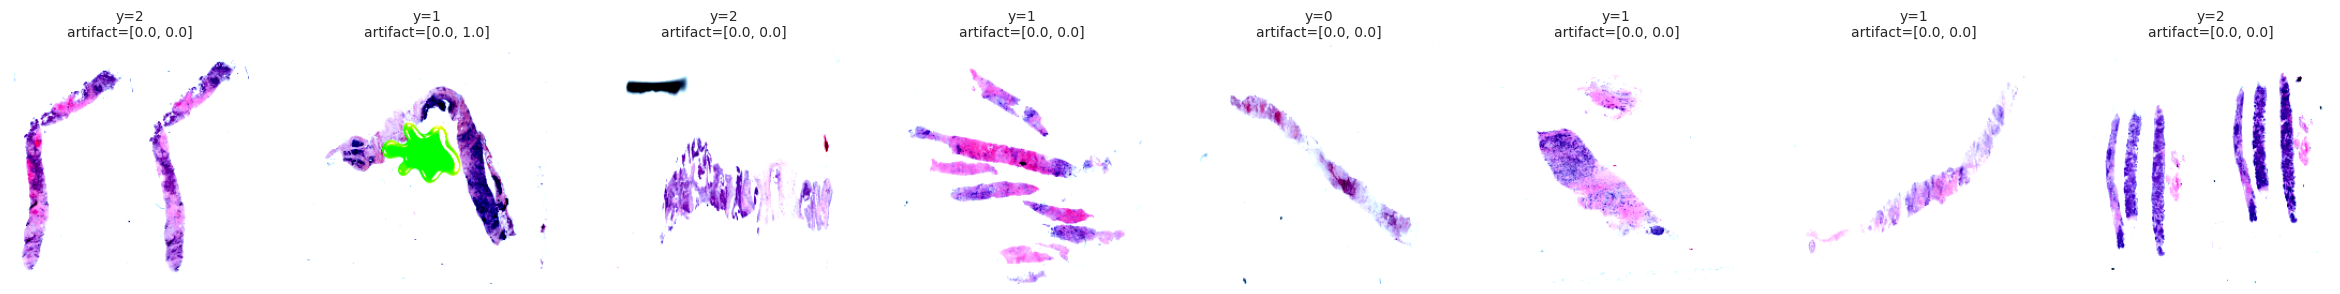

Val batch shapes: torch.Size([32, 3, 224, 224]) torch.Size([32, 2]) torch.Size([32])


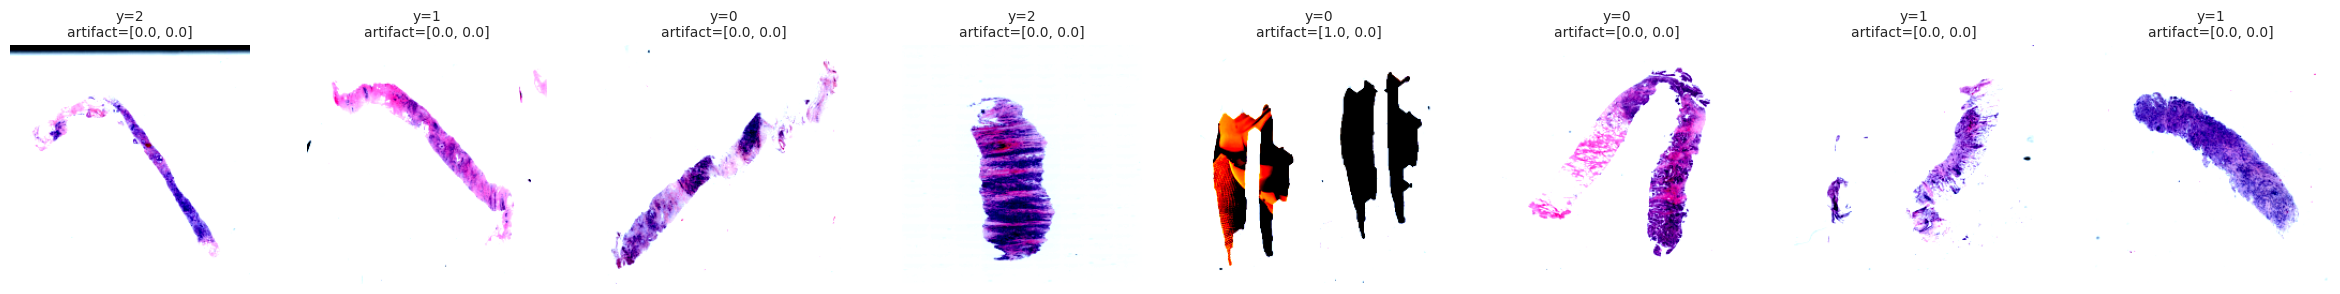

Submission batch shapes: torch.Size([32, 3, 224, 224]) torch.Size([32, 2]) torch.Size([32])


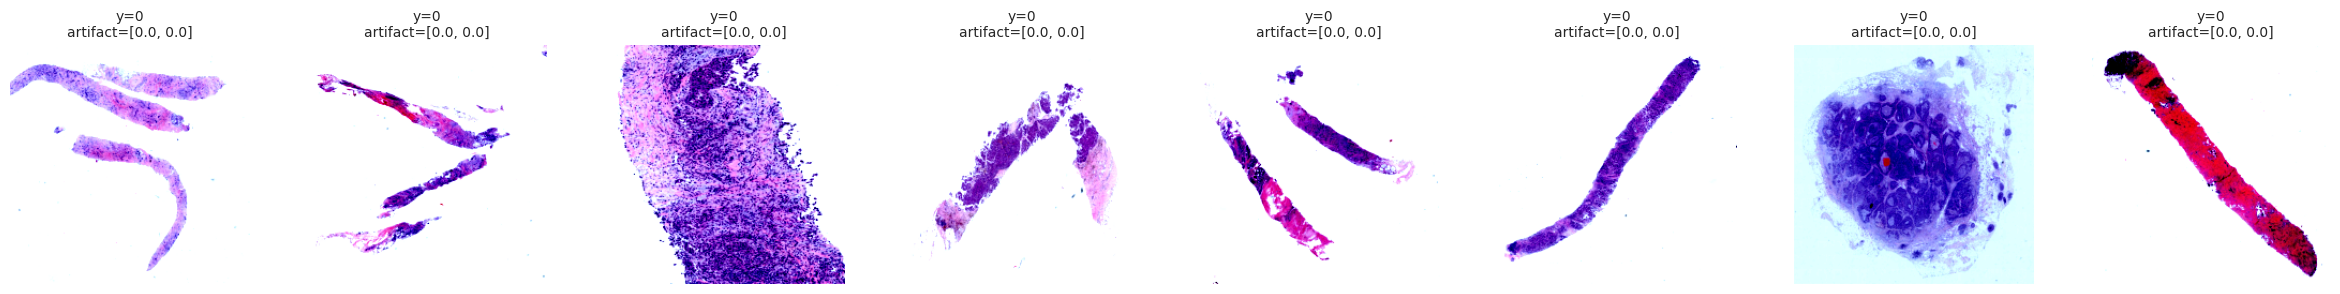

In [24]:
# -----------------------------
# Check batch
# -----------------------------
images, flags, labels = next(iter(train_loader))
print("Train batch shapes:", images.shape, flags.shape, labels.shape)
show_batch(images, flags, labels, n=8)
images, flags, labels = next(iter(val_loader))
print("Val batch shapes:", images.shape, flags.shape, labels.shape)
show_batch(images, flags, labels, n=8)

images, flags, labels = next(iter(submission_loader))
print("Submission batch shapes:", images.shape, flags.shape, labels.shape)
show_batch(images, flags, labels, n=8)


## 🔎 **Exploration and Data Analysis**

#### Class distribution

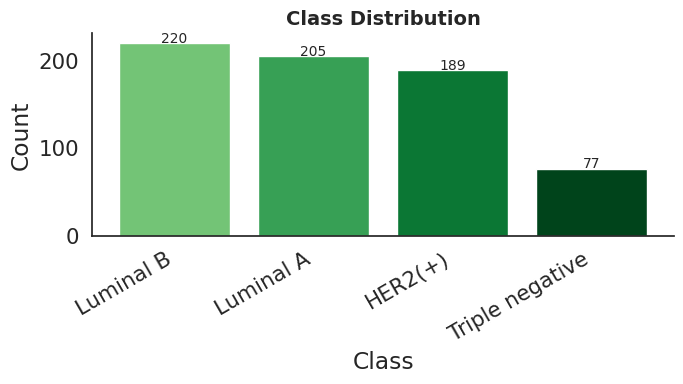

In [25]:
# @title
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm
import numpy as np

# Cleaner font and style
rcParams["font.size"] = 12
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False

# Count samples per class
counts = labels_df["label"].value_counts()

# Create a green color scale
colors = cm.Greens(np.linspace(0.5, 1, len(counts)))  # medium to light green

# Create figure and axes with transparent background
fig, ax = plt.subplots(figsize=(7, 4), facecolor="none")  # figure transparent
ax.set_facecolor("none")  # axes transparent

# Bar plot
bars = ax.bar(counts.index, counts.values, color=colors)

# Titles and labels
ax.set_title("Class Distribution", fontsize=14, weight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(int(height)),
            ha="center", fontsize=10)

plt.tight_layout()

# Save with transparent background
plt.show()


## 👁️ **Convolutional Neural Networks**

### 🧮 **Network Parameters**

In [26]:
# Count samples per class
class_counts = np.bincount(labels_df["label_mapped"].values)
num_classes = len(class_counts)

# Inverse frequency weighting (common choice)
class_weights = 1.0 / class_counts

# Convert to tensor
class_weights = torch.tensor(class_weights, dtype=torch.float32)



In [27]:
# Number of training epochs
LEARNING_RATE = 5e-3
EPOCHS = 15
PATIENCE = 10

# Regularisation
DROPOUT_RATE = 0.3        # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0            # L2 penalty

# Set up loss function and optimizer
class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rare:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("L1 Penalty:", L1_LAMBDA)
print("L2 Penalty:", L2_LAMBDA)

Epochs: 15
Batch Size: 32
Learning Rare: 0.005
Dropout Rate: 0.3
L1 Penalty: 0
L2 Penalty: 0


In [28]:
# CNN Architecture parameters
# Number of convolutional blocks
NUM_BLOCKS = 4

# Number of conv layers per block
CONVS_PER_BLOCK = 1

# Use strided convolutions instead of pooling
USE_STRIDE = False

# Stride value when USE_STRIDE is True
STRIDE_VALUE = 2

# Padding size
PADDING_SIZE = 1

# Pooling size when USE_STRIDE is False
POOL_SIZE = 2

# Number of channels in first block
INITIAL_CHANNELS = 64

# Channel multiplication factor between blocks
CHANNEL_MULTIPLIER = 2

print("Num Blocks:", NUM_BLOCKS)
print("Convs per Block:", CONVS_PER_BLOCK)
print("Use Stride:", USE_STRIDE)
print("Stride Value:", STRIDE_VALUE)
print("Padding Size:", PADDING_SIZE)
print("Pool Size:", POOL_SIZE)
print("Initial Channels:", INITIAL_CHANNELS)
print("Channel Multiplier:", CHANNEL_MULTIPLIER)

Num Blocks: 4
Convs per Block: 1
Use Stride: False
Stride Value: 2
Padding Size: 1
Pool Size: 2
Initial Channels: 64
Channel Multiplier: 2


#### Neural Networks

In [29]:
!pip install -U timm>=0.9.12


In [30]:
import torch
import torch.nn as nn

class VanillaCNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs=1, use_stride=False, stride_value=2, padding_size=1, pool_size=2):
        super().__init__()

        layers = []

        # First convolution: in_channels -> out_channels
        if num_convs == 1:
            stride = stride_value if use_stride else 1
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))
        else:
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1))
            for i in range(1, num_convs - 1):
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1))
            stride = stride_value if use_stride else 1
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))

        layers.append(nn.ReLU())
        if not use_stride:
            layers.append(nn.MaxPool2d(kernel_size=pool_size, stride=pool_size))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CNN(nn.Module):
    """
    Vanilla CNN for 4-channel input (RGB+mask) with optional late-fusion flags handled outside.
    """
    def __init__(self, input_shape, num_classes=4, dropout_rate=0.5,
                 num_blocks=3, convs_per_block=2,
                 use_stride=False, stride_value=2, padding_size=1, pool_size=2,
                 initial_channels=32, channel_multiplier=2):
        super().__init__()

        blocks = []
        in_channels = input_shape[0]  # should be 4 now (RGB+mask)
        out_channels = initial_channels

        for i in range(num_blocks):
            blocks.append(VanillaCNNBlock(
                in_channels=in_channels,
                out_channels=out_channels,
                num_convs=convs_per_block,
                use_stride=use_stride,
                stride_value=stride_value,
                padding_size=padding_size,
                pool_size=pool_size
            ))
            in_channels = out_channels
            out_channels = out_channels * channel_multiplier

        self.features = nn.Sequential(*blocks)

        # Flattened feature size
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self.features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier_head(x)
        return x


class DenseNet121_6ch(nn.Module):
    def __init__(self,
                 input_shape,
                 num_classes=4,
                 dropout_rate=0.0,
                 num_blocks=None,
                 convs_per_block=None,
                 use_stride=None,
                 stride_value=None,
                 padding_size=None,
                 pool_size=None,
                 initial_channels=None,
                 channel_multiplier=None):
        super().__init__()

        # ----------------------------
        # Load pretrained DenseNet121
        # ----------------------------
        self.model = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1
        )

        # ----------------------------
        # Modify first conv to accept 6 channels
        # ----------------------------
        old_conv = self.model.features.conv0

        new_conv = nn.Conv2d(
            in_channels=input_shape[0],         # expected 6
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        # Weight initialization
        with torch.no_grad():
            if input_shape[0] >= 3:
                # Copy pretrained RGB weights
                new_conv.weight[:, :3, :, :] = old_conv.weight

                # Extra channels initialized as mean of RGB
                mean_rgb = old_conv.weight.mean(dim=1, keepdim=True)
                for ch in range(3, input_shape[0]):
                    new_conv.weight[:, ch:ch+1, :, :] = mean_rgb
            else:
                # Edge case: fewer than 3 channels (not your case)
                new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

        # Replace layer
        self.model.features.conv0 = new_conv

        # ----------------------------
        # Replace classifier head
        # ----------------------------
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

import torch
import torch.nn as nn

class VanillaCNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs=1, use_stride=False, stride_value=2, padding_size=1, pool_size=2):
        super().__init__()
        layers = []

        if num_convs == 1:
            stride = stride_value if use_stride else 1
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))
        else:
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1))
            for _ in range(1, num_convs-1):
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1))
            stride = stride_value if use_stride else 1
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))

        layers.append(nn.ReLU())
        if not use_stride:
            layers.append(nn.MaxPool2d(kernel_size=pool_size, stride=pool_size))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class VanillaCNN(nn.Module):
    """
    Vanilla CNN for 4-channel input (RGB+mask) with optional late-fusion flags.
    """
    def __init__(self, input_shape, num_classes=4, dropout_rate=0.5,
                 num_blocks=3, convs_per_block=2,
                 use_stride=False, stride_value=2, padding_size=1, pool_size=2,
                 initial_channels=32, channel_multiplier=2,
                 flags_dim=2, flags_mlp_hidden=16):
        super().__init__()

        # CNN backbone
        blocks = []
        in_channels = input_shape[0]  # 4 (RGB + mask)
        out_channels = initial_channels

        for _ in range(num_blocks):
            blocks.append(VanillaCNNBlock(
                in_channels=in_channels,
                out_channels=out_channels,
                num_convs=convs_per_block,
                use_stride=use_stride,
                stride_value=stride_value,
                padding_size=padding_size,
                pool_size=pool_size
            ))
            in_channels = out_channels
            out_channels = out_channels * channel_multiplier

        self.features = nn.Sequential(*blocks)

        # Compute flattened feature size
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            flattened_size = self.features(dummy_input).view(1, -1).shape[1]

        # Optional flags MLP
        self.flags_mlp = nn.Sequential(
            nn.Linear(flags_dim, flags_mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # Final classifier after fusion
        self.classifier = nn.Sequential(
            nn.Linear(flattened_size + flags_mlp_hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x_img, x_flags):
        """
        x_img: [B, 4, H, W] (RGB + mask)
        x_flags: [B, 2] (artifact flags)
        """
        img_feat = self.features(x_img)
        img_feat = img_feat.view(img_feat.size(0), -1)

        flag_feat = self.flags_mlp(x_flags)
        fused = torch.cat([img_feat, flag_feat], dim=1)

        out = self.classifier(fused)
        return out



import torch
import torch.nn as nn
from torchvision import models

class DenseNet121_6ch_LateFusion(nn.Module):
    def __init__(self,
                 input_shape,
                 num_classes=4,
                 dropout_rate=0.0,
                 num_blocks=None,
                 convs_per_block=None,
                 use_stride=None,
                 stride_value=None,
                 padding_size=None,
                 pool_size=None,
                 initial_channels=None,
                 channel_multiplier=None,
                 flags_dim=2,
                 mlp_hidden=8,
                 pretrained=True):
        """
        DenseNet121 with late-fusion of artifact flags.
        input_shape: (C,H,W) for the image input (e.g., 4 channels: RGB + mask)
        flags_dim: number of artifact flags (default=2)
        mlp_hidden: hidden size for flags MLP
        """
        super().__init__()

        # ----------------------------
        # Pretrained DenseNet121
        # ----------------------------
        self.model = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        )

        # Modify first conv to accept input_shape[0] channels
        old_conv = self.model.features.conv0
        new_conv = nn.Conv2d(
            in_channels=input_shape[0],
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        # Initialize weights
        with torch.no_grad():
            if input_shape[0] >= 3:
                # Copy pretrained RGB weights
                new_conv.weight[:, :3, :, :] = old_conv.weight
                # Extra channels initialized as mean of RGB
                mean_rgb = old_conv.weight.mean(dim=1, keepdim=True)
                for ch in range(3, input_shape[0]):
                    new_conv.weight[:, ch:ch+1, :, :] = mean_rgb
            else:
                new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

        self.model.features.conv0 = new_conv

        # Remove classifier
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Identity()

        # ----------------------------
        # Artifact flags MLP
        # ----------------------------
        self.flags_mlp = nn.Sequential(
            nn.Linear(flags_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # ----------------------------
        # Final classifier after fusion
        # ----------------------------
        self.classifier = nn.Sequential(
            nn.Linear(in_features + mlp_hidden, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x_img, x_flags):
        """
        x_img: [B, C, H, W]  (C=input_shape[0], e.g., 4)
        x_flags: [B, flags_dim] (e.g., 2)
        """
        img_feat = self.model(x_img)
        flag_feat = self.flags_mlp(x_flags)
        fused = torch.cat([img_feat, flag_feat], dim=1)
        out = self.classifier(fused)
        return out

import timm

import torch
import torch.nn as nn
import timm

import torch
import torch.nn as nn
import timm
from timm.layers import SwiGLUPacked

class Virchow2_6ch_LateFusion(nn.Module):
    def __init__(
        self,
        input_shape,
        num_classes=4,
        dropout_rate=0.4,
        flags_dim=2,
        mlp_hidden=8,
    ):
        """
        Virchow2 ViT-H/14 backbone with late fusion of artifact flags.
        OOM-safe configuration (frozen backbone, CLS-only embedding).

        input_shape: (C, H, W)
        """
        super().__init__()

        # --------------------------------------------------
        # Virchow2 backbone (OFFICIAL CONFIG)
        # --------------------------------------------------
        self.backbone = timm.create_model(
            "hf-hub:paige-ai/Virchow2",
            pretrained=True,
            num_classes=0,
            mlp_layer=SwiGLUPacked,
            act_layer=nn.SiLU,
        )

        # 🔒 Freeze backbone (INTENDED USAGE)
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.backbone.eval()

        # CLS token only → 1280-dim
        self.virchow_embed_dim = self.backbone.num_features  # 1280

        # --------------------------------------------------
        # Channel projection (Virchow2 expects RGB)
        # --------------------------------------------------
        in_channels = input_shape[0]
        if in_channels != 3:
            self.channel_proj = nn.Conv2d(
                in_channels, 3, kernel_size=1, bias=False
            )
        else:
            self.channel_proj = nn.Identity()

        # --------------------------------------------------
        # Artifact flags MLP
        # --------------------------------------------------
        self.flags_mlp = nn.Sequential(
            nn.Linear(flags_dim, mlp_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
        )

        # --------------------------------------------------
        # Final classifier (late fusion)
        # --------------------------------------------------
        self.classifier = nn.Sequential(
            nn.Linear(self.virchow_embed_dim + mlp_hidden, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

    def forward(self, x_img, x_flags):
        """
        x_img:   [B, C, H, W]
        x_flags: [B, flags_dim]
        """

        # Project channels → RGB
        x_img = self.channel_proj(x_img)

        # --------------------------------------------------
        # Virchow2 forward (NO GRADS, NO ACTIVATION STORAGE)
        # --------------------------------------------------
        with torch.inference_mode():
            tokens = self.backbone(x_img)  # [B, 261, 1280]
            img_embedding = tokens[:, 0]   # CLS token only

        # Flags
        flag_feat = self.flags_mlp(x_flags)

        # Late fusion
        fused = torch.cat([img_embedding, flag_feat], dim=1)
        out = self.classifier(fused)

        return out



In [31]:
# --- Get a sample from the dataset ---
cnn_input, _ , sample_label = full_dataset[0]  # cnn_input already includes image + mask + flags

print("CNN input shape (C, H, W):", cnn_input.shape)  # e.g., (6, H, W)
print("Label:", sample_label)

# --- Use this shape for defining the CNN ---
input_shape = cnn_input.shape


CNN input shape (C, H, W): torch.Size([3, 224, 224])
Label: tensor(3)


In [32]:
from torch.utils.tensorboard import SummaryWriter
import torch

# ----------------------------
# Set up TensorBoard logging
# ----------------------------
experiment_name = "cnn_late_fusion"
writer = SummaryWriter("./" + logs_dir + "/" + experiment_name)

# Dummy inputs
batch_size = 1
x_img = torch.randn(batch_size, input_shape[0], input_shape[1], input_shape[2]).to(device)  # RGB + mask
x_flags = torch.randn(batch_size, 2).to(device)  # Artifact flags

# Add model graph
writer.add_graph(cnn_model, (x_img, x_flags))  # Pass as a tuple

# ----------------------------
# Optimizer
# ----------------------------
optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# ----------------------------
# Mixed precision scaler
# ----------------------------
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))


### 🧠 **Model Training**

In [33]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [34]:
import numpy as np
import torch
from sklearn.metrics import f1_score

def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch for late-fusion model (image + flags).

    Args:
        model (nn.Module): The CNN or DenseNet model to train
        train_loader (DataLoader): DataLoader with training batches
        criterion (nn.Module): Loss function
        optimizer (torch.optim): Optimization algorithm
        scaler (GradScaler): Mixed precision scaler
        device (torch.device): Computing device
        l1_lambda (float): L1 regularization weight
        l2_lambda (float): L2 regularization weight

    Returns:
        tuple: (average_loss, f1_score) for the epoch
    """
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for x_img, x_flags, targets in train_loader:
        x_img = x_img.to(device)
        x_flags = x_flags.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(x_img, x_flags)  # pass both image and flags
            loss = criterion(logits, targets)

            # L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters() if p.requires_grad and p.dim() > 1)
            l2_norm = sum(p.pow(2).sum() for p in model.parameters() if p.requires_grad and p.dim() > 1)
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * x_img.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1


In [35]:
import numpy as np
import torch
from sklearn.metrics import f1_score

def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch for late-fusion model (image + flags).

    Args:
        model (nn.Module): Neural network model
        val_loader (DataLoader): Validation DataLoader
        criterion (nn.Module): Loss function
        device (torch.device): Computing device

    Returns:
        tuple: (average_loss, weighted_f1_score) for the epoch
    """
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for x_img, x_flags, targets in val_loader:
            x_img = x_img.to(device)
            x_flags = x_flags.to(device)
            targets = targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(x_img, x_flags)  # pass both image and flags
                loss = criterion(logits, targets)

            running_loss += loss.item() * x_img.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1


In [36]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [37]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [38]:

%%time
# Train model and track training history
cnn_model, training_history = fit(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="cnn",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = cnn_model
    best_performance = max(training_history['val_f1'])

Training 15 epochs...
Epoch   1/15 | Train: Loss=2.9199, F1 Score=0.2711 | Val: Loss=1.3745, F1 Score=0.2607
Epoch   2/15 | Train: Loss=1.2534, F1 Score=0.4187 | Val: Loss=1.2129, F1 Score=0.4186
Epoch   3/15 | Train: Loss=1.2145, F1 Score=0.4339 | Val: Loss=1.1878, F1 Score=0.4955
Epoch   4/15 | Train: Loss=1.1580, F1 Score=0.4373 | Val: Loss=1.1713, F1 Score=0.5073
Epoch   5/15 | Train: Loss=1.1477, F1 Score=0.4706 | Val: Loss=1.1860, F1 Score=0.5224
Epoch   6/15 | Train: Loss=1.1197, F1 Score=0.4954 | Val: Loss=1.1309, F1 Score=0.4646
Epoch   7/15 | Train: Loss=1.1004, F1 Score=0.4854 | Val: Loss=1.1658, F1 Score=0.5036
Epoch   8/15 | Train: Loss=1.0798, F1 Score=0.5226 | Val: Loss=1.1574, F1 Score=0.5152
Epoch   9/15 | Train: Loss=1.0780, F1 Score=0.4843 | Val: Loss=1.2567, F1 Score=0.3625
Epoch  10/15 | Train: Loss=1.0870, F1 Score=0.4964 | Val: Loss=1.2515, F1 Score=0.4541
Epoch  11/15 | Train: Loss=1.1123, F1 Score=0.4482 | Val: Loss=1.2167, F1 Score=0.4865
Epoch  12/15 | Train:

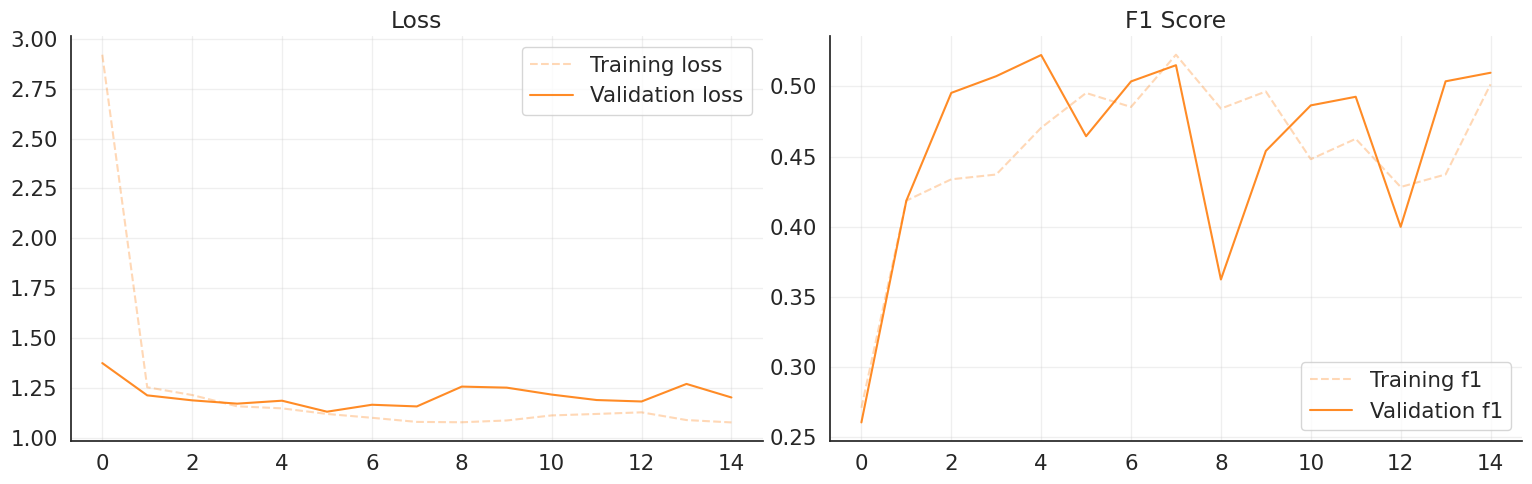

In [39]:
# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.5286
Precision over the validation set: 0.5910
Recall over the validation set: 0.5286
F1 score over the validation set: 0.5224


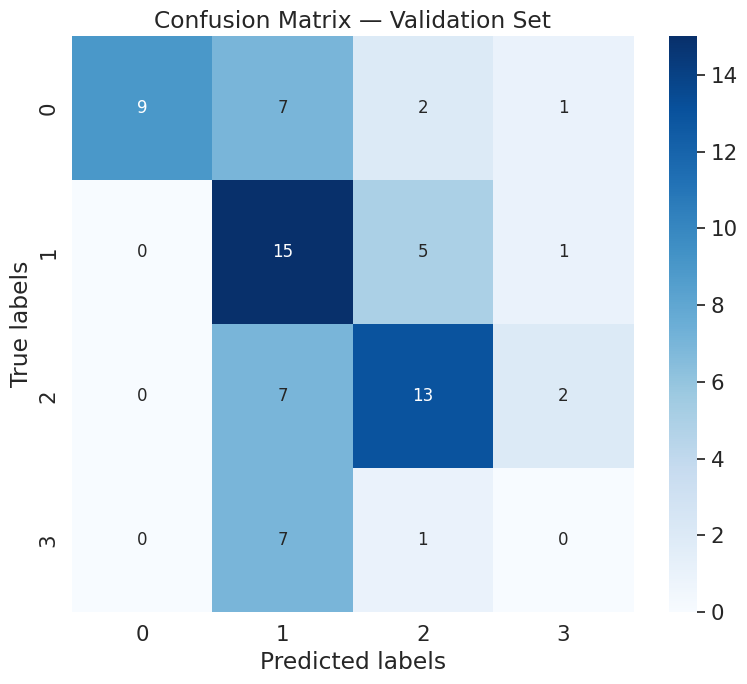

In [40]:
# @title Plot Confusion Matrix (Late-Fusion Model)
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

val_preds, val_targets = [], []

with torch.no_grad():  # Disable gradient computation
    for x_img, x_flags, yb in val_loader:
        x_img = x_img.to(device)
        x_flags = x_flags.to(device)
        yb = yb.to(device)

        # Forward pass
        logits = cnn_model(x_img, x_flags)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store results
        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())

# Combine all batches
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Compute metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Confusion matrix
cm = confusion_matrix(val_targets, val_preds)
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Plot heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()


In [41]:
from sklearn.metrics import f1_score, classification_report

all_preds = []
all_targets = []

with torch.no_grad():
    for x_img, x_flags, yb in val_loader:
        x_img = x_img.to(device)
        x_flags = x_flags.to(device)
        yb = yb.to(device)

        logits = cnn_model(x_img, x_flags)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

# Flatten all batches
all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Per-class F1
per_class_f1 = f1_score(all_targets, all_preds, average=None)
print("Per-class F1:", per_class_f1)

# Optional: full classification report
print(classification_report(all_targets, all_preds, target_names=[str(k) for k in mapping.keys()]))


Per-class F1: [0.64285714 0.52631579 0.60465116 0.        ]
                 precision    recall  f1-score   support

        HER2(+)       1.00      0.47      0.64        19
      Luminal A       0.42      0.71      0.53        21
      Luminal B       0.62      0.59      0.60        22
Triple negative       0.00      0.00      0.00         8

       accuracy                           0.53        70
      macro avg       0.51      0.44      0.44        70
   weighted avg       0.59      0.53      0.52        70



## 📤 Create Submission

In [42]:
import numpy as np
import pandas as pd
import torch

cnn_model.eval()
submission_preds = []

with torch.no_grad():  # Disable gradient computation for inference
    for x_img, x_flags, _ in submission_loader:  # ignore dummy labels
        x_img = x_img.to(device)
        x_flags = x_flags.to(device)

        # Forward pass
        logits = cnn_model(x_img, x_flags)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        submission_preds.append(preds)

# Combine all batches
submission_preds = np.concatenate(submission_preds)

# Map integer predictions to label names
inv_label_mapping = {v: k for k, v in mapping.items()}
submission_labels = np.array([inv_label_mapping[p] for p in submission_preds])

# Create DataFrame with sequence-level predictions
output = pd.DataFrame({
    'sample_index': submission_files,
    'label': submission_labels
})

output.head(20)


,sample_index,label
0,img_0000.png,Luminal B
1,img_0001.png,Luminal A
2,img_0002.png,Luminal A
3,img_0003.png,Luminal B
4,img_0004.png,Luminal A
5,img_0005.png,Luminal B
6,img_0006.png,Triple negative
7,img_0007.png,Luminal A
8,img_0008.png,Luminal B
9,img_0009.png,Luminal B


In [43]:
# Define the filename
filename = "submission_from_notebook_"+str(best_performance)+".csv"
if(TRAIN_ON_WHOLE_SET):
  filename = "submission_from_notebook_WHOLE.csv" # removes validation score as it would make no sense

# Remove the file if it already exists
if os.path.exists(filename):
    os.remove(filename)

# Now safely write the new file
output.to_csv(filename, index=False)

## 🛫 Send Submission

In [44]:
message = "sent automatically from colab notebook"
if SUBMIT_PREDICTION:
    !kaggle competitions submit -c an2dl2526c2v2 -f $filename -m "$message"

100% 10.9k/10.9k [00:01<00:00, 7.06kB/s]
Successfully submitted to AN2DL [2025-2026]: Image Classification 2.0